<a href="https://colab.research.google.com/github/swathishenoy25/AI-ML/blob/aiml/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Project to produict if a perosn has diabetes(Yes or No) using medical features like glucose, insulin, bmi etc


In [2]:
#Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
#read the dataset
df = pd.read_csv('diabetes.csv')

In [12]:
#first few rows

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [18]:
#Cleaning up data, fill up missing data

zero_missing=['Glucose', 'BloodPressure', 'Insulin','SkinThickness', 'BMI']
df[zero_missing] =df[zero_missing].replace(0, np.nan)

df.fillna(df.mean(), inplace=True)

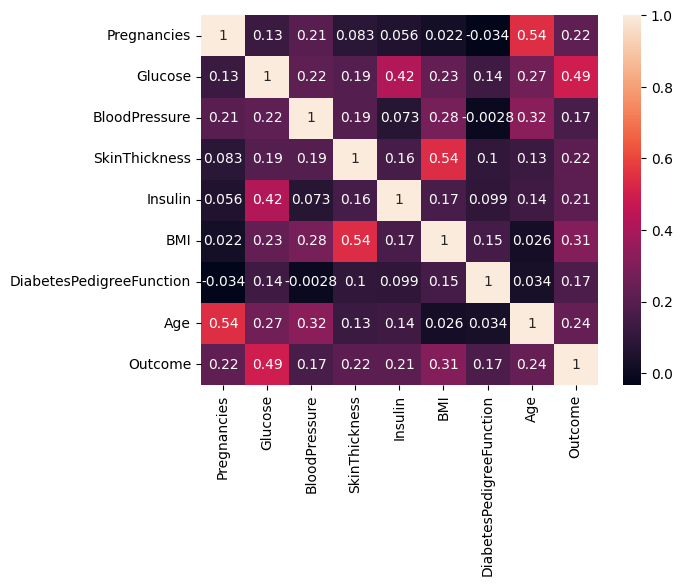

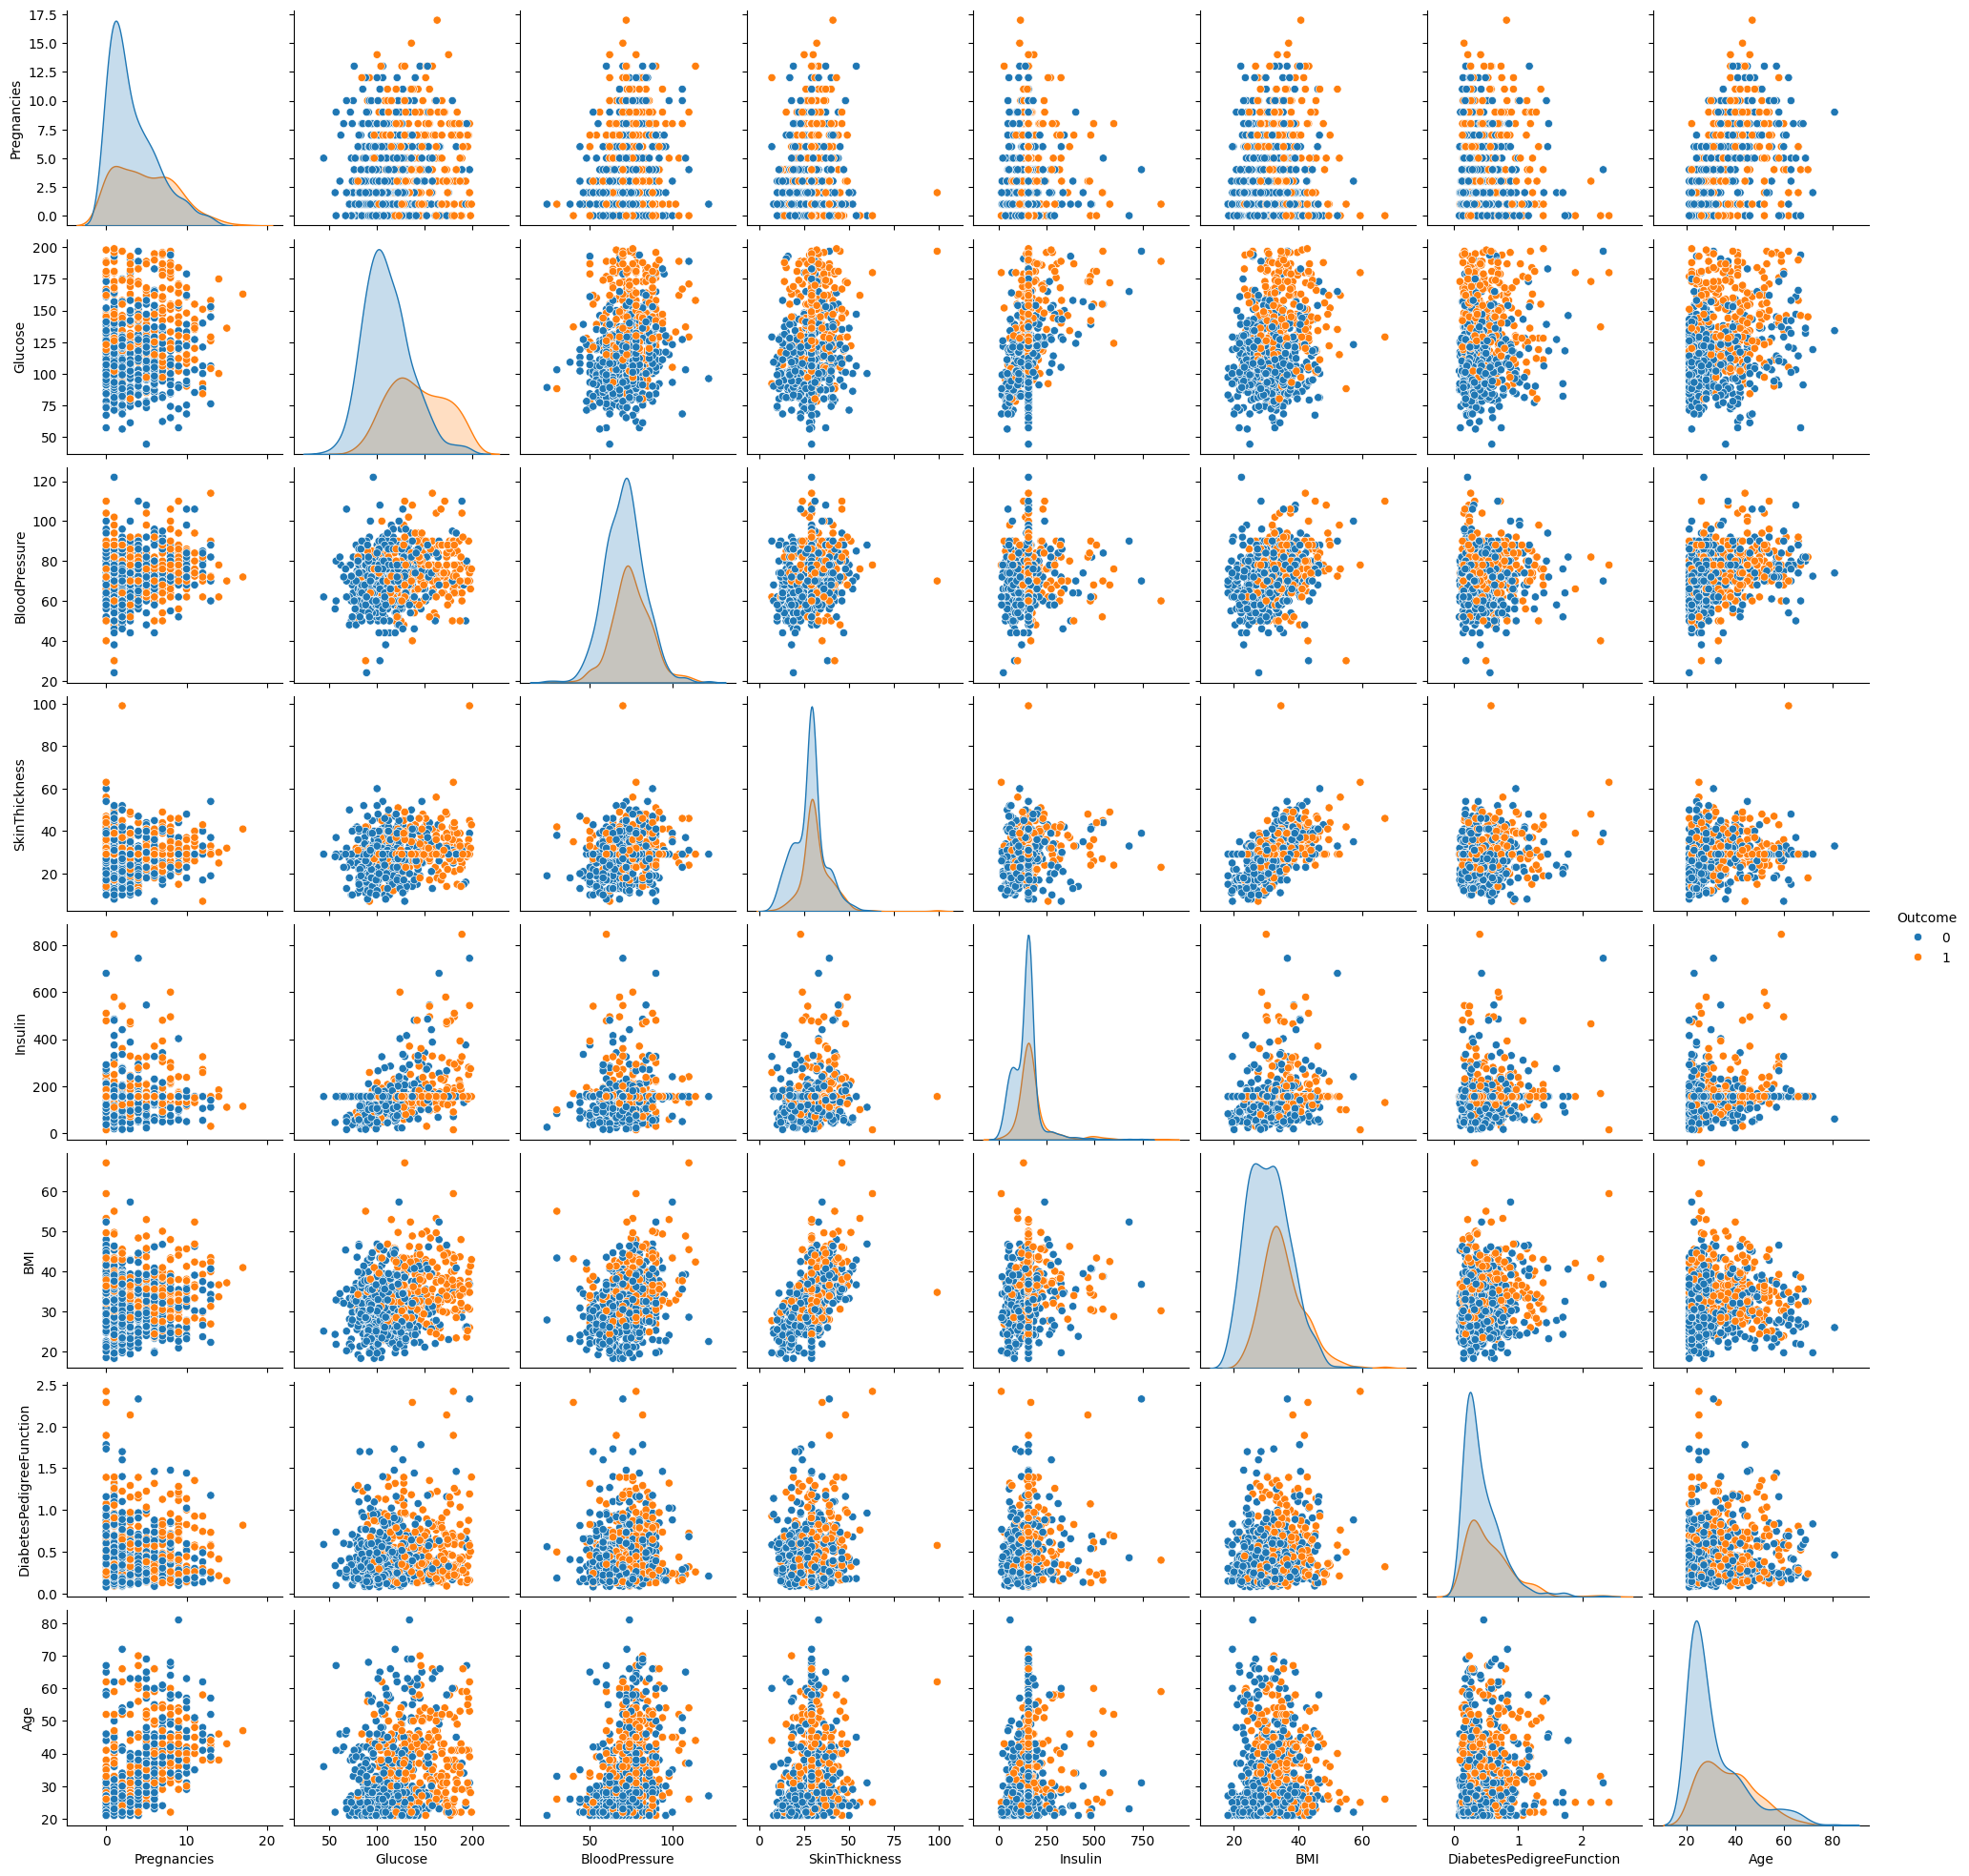

In [19]:
#visualisation

sns.heatmap(df.corr(), annot=True)
sns.pairplot(df, hue='Outcome')


In [20]:
#Preprocessing-Handling zero values, feature target split, train-test split, scale features.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

model=LogisticRegression(max_iter=250)
x= df.drop('Outcome', axis=1)
y=df['Outcome']

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=42)

model.fit(x_train, y_train)


LogisticRegression(max_iter=250)

In [27]:
#Modelling using Logical Regression

from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(x_test)
print("-----Logical Regression-----")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

-----Logical Regression-----
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

[[82 17]
 [21 34]]
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [22]:
#Trying the same with Random Forest

from sklearn.ensemble import RandomForestClassifier

In [23]:
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [26]:
y_pred_rf = rf_model.predict(x_test)

print("-----Random Forest-----")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

-----Random Forest-----
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

[[80 19]
 [19 36]]
